# Phase 6 — Cost-Aware Decision Rule + ROI Sweep

Model probabilities + intervention menu + LTV → **per-user targeting decisions with a
budget cap**. Then compare against the blanket $5 credit campaign the retention team
runs today.

## Sections

| Section | Purpose |
|---|---|
| **A. Setup** | Load model, score all subscribers |
| **B. Assumptions** | Intervention menu, LTV, cost, uplift |
| **C. Per-lever EV** | Compute EV for each lever, per user |
| **D. Best-lever selection** | Argmax over levers |
| **E. Budget cap** | Apply $200k cap + policy summary |
| **F. Baseline comparison** | Head-to-head vs blanket $5 credit at m11 |
| **G. ROI sweep** | Revenue / cost / net-EV across 25 budget levels |
| **H. Sensitivity** | Uplift assumption robustness |
| **I. Verdict** | Handoff to Phase 7 (memo + Streamlit app) |

All figures saved under `reports/figures/`.

In [1]:
import os
import sys
import pickle
from pathlib import Path

# Run from project root whether invoked as `python notebooks/06_...` or
# from a Jupyter cell (which doesn't define __file__).
try:
    _project_root = Path(__file__).resolve().parents[1]
except NameError:
    _here = Path.cwd()
    _project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(_project_root)
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import prepare_features
from src.models.production import load_production_churn_model
from src.decisions.policy import (
    INTERVENTION_MENU, LTV_BY_TIER, PREMIUM_UPGRADE_CAP_PCT,
    score_all_levers, pick_best_lever, apply_budget_cap,
    apply_premium_cap, summarize_policy, simulate_blanket_campaign,
)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## A. Setup — score every subscriber with the calibrated model

In [2]:
print("=" * 70)
print("A. SETUP")
print("=" * 70)

raw = load_subscribers("data/subscribers.csv")
df = build_features(raw)
X, y = prepare_features(df)

# Load via src/models/production.py so we're guaranteed to be reading
# the same artifact Phase 4 wrote and Streamlit also reads from.
model, artifact = load_production_churn_model()
feature_names = artifact["feature_names"]

# Align feature order to what the model was trained on
X = X[feature_names]

p_churn = model.predict_proba(X)[:, 1]
ltv = df["plan_tier"].map(LTV_BY_TIER).values
tenure = df["tenure_months"].values

print(f"Scored {len(p_churn):,} subscribers")
print(f"P(churn) distribution -- mean={p_churn.mean():.4f}, "
      f"p90={np.percentile(p_churn, 90):.4f}, "
      f"max={p_churn.max():.4f}")
print(f"LTV distribution     -- mean=${ltv.mean():.0f}, "
      f"min=${ltv.min():.0f}, max=${ltv.max():.0f}")

A. SETUP
Scored 50,000 subscribers
P(churn) distribution -- mean=0.0532, p90=0.0748, max=0.9693
LTV distribution     -- mean=$130, min=$72, max=$228


## B. Assumptions — intervention menu, LTV, uplift, guardrails

All numbers curated with the PM (`reports/scenario_brief.md`). Uplifts are from the
PM's 2024 pilot; sensitivity in Section H sweeps ±50%.

In [3]:
print("\n" + "=" * 70)
print("B. ASSUMPTIONS")
print("=" * 70)
print("\nIntervention menu:")
menu_df = pd.DataFrame(INTERVENTION_MENU).T
menu_df["cost"] = menu_df["cost"].map("${:.2f}".format)
menu_df["uplift"] = menu_df["uplift"].map("{:.0%}".format)
print(menu_df)

print("\nLTV by tier (monthly_revenue x retained months):")
for tier, v in LTV_BY_TIER.items():
    print(f"  {tier:<10}  ${v:.0f}")
print(f"\nPremium upgrade cap: {PREMIUM_UPGRADE_CAP_PCT:.0%} of base")


B. ASSUMPTIONS

Intervention menu:
                    cost uplift
curated_playlist   $1.00     5%
credit_5           $5.00    15%
premium_upgrade   $12.00    25%

LTV by tier (monthly_revenue x retained months):
  Basic       $72
  Standard    $140
  Premium     $228

Premium upgrade cap: 5% of base


## C. Expected value per lever, per user

For each of the 50K subscribers × 3 levers, compute
`EV = P(churn) × uplift × LTV − cost`. Wide-format matrix that Section D reduces to
best-lever-per-user.

In [4]:
print("\n" + "=" * 70)
print("C. EV PER LEVER PER USER")
print("=" * 70)
ev_wide = score_all_levers(p_churn, ltv, INTERVENTION_MENU)
print("\nEV summary across all users:")
print(ev_wide.describe().T[["mean", "50%", "max"]].round(2))


C. EV PER LEVER PER USER

EV summary across all users:
                      mean    50%   max
ev_curated_playlist  -0.67  -0.75   9.4
ev_credit_5          -4.00  -4.26  26.2
ev_premium_upgrade  -10.33 -10.76  40.0


## D. Best-lever selection

`argmax` over levers per user. Users with all-negative EVs get `best_lever = "none"`
(skip the intervention entirely). Distribution shows how many users route to each
lever before the budget cap is applied.

In [5]:
print("\n" + "=" * 70)
print("D. BEST-LEVER SELECTION")
print("=" * 70)
policy = pick_best_lever(p_churn, ltv, INTERVENTION_MENU)
print("\nBest-lever distribution (before budget cap):")
print(policy["best_lever"].value_counts().to_string())


D. BEST-LEVER SELECTION

Best-lever distribution (before budget cap):
best_lever
none                48490
curated_playlist     1023
credit_5              330
premium_upgrade       157


## E. Budget cap ($200k) + policy summary

Sort actionable users by EV descending, cumulative-cost cutoff at the budget line, and
also apply the **5% premium-upgrade cap** (guardrail: can't offer too many free-tier
upgrades without margin compression).

In [6]:
print("\n" + "=" * 70)
print("E. BUDGET CAP + SUMMARY")
print("=" * 70)
BUDGET = 200_000.0
policy = apply_budget_cap(policy, budget=BUDGET)
policy = apply_premium_cap(policy, n_total=len(policy),
                           cap_pct=PREMIUM_UPGRADE_CAP_PCT)

targeted = policy[policy["will_target"]]
print(f"\nBudget cap: ${BUDGET:,.0f}")
print(f"Users targeted: {len(targeted):,} of {len(policy):,} "
      f"({len(targeted)/len(policy):.1%})")
print(f"\nLever mix (targeted only):")
print(targeted["best_lever"].value_counts().to_string())

summary = summarize_policy(policy, targeted_only=True)
print(f"\nExpected outcome under the targeted policy:")
print(f"  Total cost:               ${summary['total_cost']:>12,.0f}")
print(f"  Expected retained revenue: ${summary['expected_retained_revenue']:>12,.0f}")
print(f"  Net expected value:        ${summary['net_expected_value']:>12,.0f}")
print(f"  ROI multiplier:           {summary['roi_multiplier']:>12.2f}x")


E. BUDGET CAP + SUMMARY

Budget cap: $200,000
Users targeted: 1,510 of 50,000 (3.0%)

Lever mix (targeted only):
best_lever
curated_playlist    1023
credit_5             330
premium_upgrade      157

Expected outcome under the targeted policy:
  Total cost:               $       4,557
  Expected retained revenue: $       7,824
  Net expected value:        $       3,267
  ROI multiplier:                   1.72x


## F. Baseline comparison — blanket $5 credit at month 11

This is what the retention team runs today: contact every user at tenure = 11 months
with a $5 credit, regardless of predicted churn. Simulate it under the same LTV +
uplift assumptions so the two policies are directly comparable.

In [7]:
print("\n" + "=" * 70)
print("F. BASELINE: BLANKET $5 CREDIT AT MONTH-11")
print("=" * 70)
baseline = simulate_blanket_campaign(
    p_churn=p_churn, ltv=ltv, tenure_months=tenure,
    cost_per_user=5.0, target_month=11, uplift=0.15,
)
print(f"\nCurrent-state baseline:")
print(f"  Users targeted (all m11):  {baseline['n_targeted']:,}")
print(f"  Total cost:               ${baseline['total_cost']:>12,.0f}")
print(f"  Expected retained revenue: ${baseline['expected_retained_revenue']:>12,.0f}")
print(f"  Net expected value:        ${baseline['net_expected_value']:>12,.0f}")
print(f"  ROI multiplier:           {baseline['roi_multiplier']:>12.2f}x")

# Head-to-head
print("\n" + "-" * 70)
print("HEAD TO HEAD")
print("-" * 70)
def _fmt(row_name, value):
    if row_name == "roi_multiplier":
        return f"{value:.2f}x"
    if row_name == "n_targeted":
        return f"{value:,.0f}"
    return f"${value:,.0f}"

head_to_head = pd.DataFrame({
    row: {col: _fmt(row, v[row])
          for col, v in [("blanket_m11", baseline), ("targeted_policy", summary)]}
    for row in ["n_targeted", "total_cost", "expected_retained_revenue",
                "net_expected_value", "roi_multiplier"]
}).T
print(head_to_head)


F. BASELINE: BLANKET $5 CREDIT AT MONTH-11

Current-state baseline:
  Users targeted (all m11):  1,587
  Total cost:               $       7,935
  Expected retained revenue: $       1,606
  Net expected value:        $      -6,329
  ROI multiplier:                   0.20x

----------------------------------------------------------------------
HEAD TO HEAD
----------------------------------------------------------------------
                          blanket_m11 targeted_policy
n_targeted                      1,587           1,510
total_cost                     $7,935          $4,557
expected_retained_revenue      $1,606          $7,824
net_expected_value            $-6,329          $3,267
roi_multiplier                  0.20x           1.72x


## G. ROI sweep across budget levels

25 budget levels from $10k to $500k. Two things worth watching: (1) net EV plateaus
fast once we've picked the ~3% of high-EV users, (2) ROI **decays** as budget grows
because we start targeting weaker candidates.


G. ROI SWEEP

Saved -> reports\figures/06_roi_sweep.png

ROI sweep table:
  budget  n_targeted   cost revenue net_ev   roi
 $10,000        1510 $4,557  $7,824 $3,267 1.72x
 $30,417        1510 $4,557  $7,824 $3,267 1.72x
 $50,833        1510 $4,557  $7,824 $3,267 1.72x
 $71,250        1510 $4,557  $7,824 $3,267 1.72x
 $91,667        1510 $4,557  $7,824 $3,267 1.72x
$112,083        1510 $4,557  $7,824 $3,267 1.72x
$132,500        1510 $4,557  $7,824 $3,267 1.72x
$152,917        1510 $4,557  $7,824 $3,267 1.72x
$173,333        1510 $4,557  $7,824 $3,267 1.72x
$193,750        1510 $4,557  $7,824 $3,267 1.72x
$214,167        1510 $4,557  $7,824 $3,267 1.72x
$234,583        1510 $4,557  $7,824 $3,267 1.72x
$255,000        1510 $4,557  $7,824 $3,267 1.72x
$275,417        1510 $4,557  $7,824 $3,267 1.72x
$295,833        1510 $4,557  $7,824 $3,267 1.72x
$316,250        1510 $4,557  $7,824 $3,267 1.72x
$336,667        1510 $4,557  $7,824 $3,267 1.72x
$357,083        1510 $4,557  $7,824 $3,267 

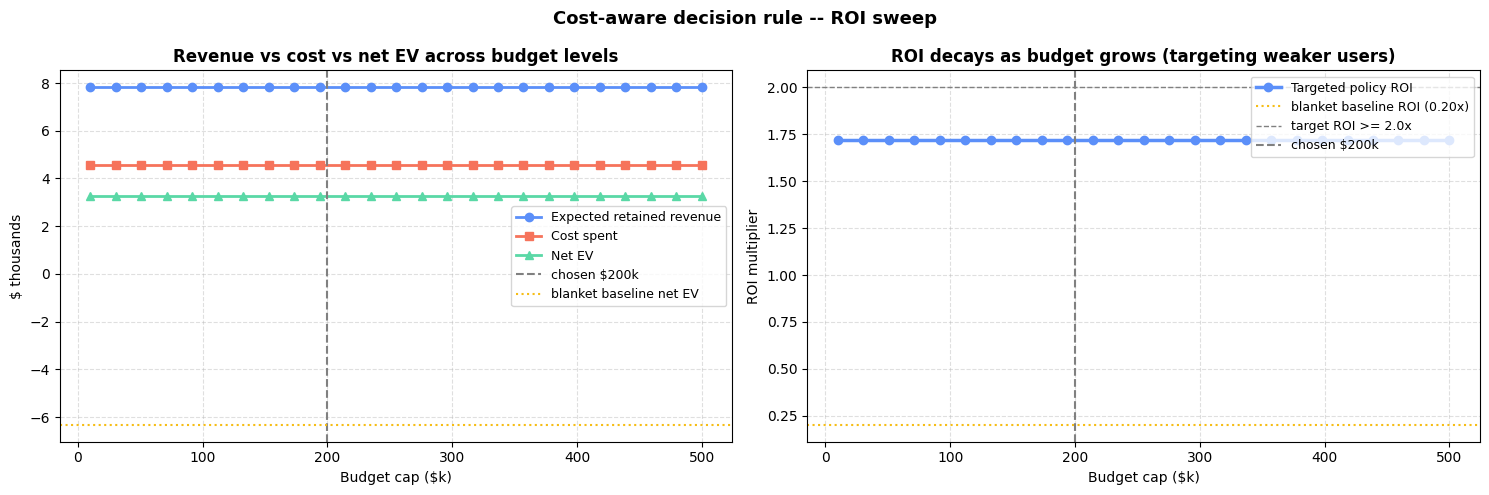

In [8]:
print("\n" + "=" * 70)
print("G. ROI SWEEP")
print("=" * 70)
budgets = np.linspace(10_000, 500_000, 25)
sweep_rows = []
for b in budgets:
    p_sweep = pick_best_lever(p_churn, ltv, INTERVENTION_MENU)
    p_sweep = apply_budget_cap(p_sweep, budget=b)
    p_sweep = apply_premium_cap(p_sweep, n_total=len(p_sweep),
                                cap_pct=PREMIUM_UPGRADE_CAP_PCT)
    s = summarize_policy(p_sweep, targeted_only=True)
    sweep_rows.append({
        "budget": b,
        "n_targeted": s["n_targeted"],
        "cost": s["total_cost"],
        "revenue": s["expected_retained_revenue"],
        "net_ev": s["net_expected_value"],
        "roi": s["roi_multiplier"],
    })
sweep = pd.DataFrame(sweep_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(sweep["budget"] / 1000, sweep["revenue"] / 1000,
         marker="o", linewidth=2, color="#5B8FF9",
         label="Expected retained revenue")
ax1.plot(sweep["budget"] / 1000, sweep["cost"] / 1000,
         marker="s", linewidth=2, color="#F6735B",
         label="Cost spent")
ax1.plot(sweep["budget"] / 1000, sweep["net_ev"] / 1000,
         marker="^", linewidth=2, color="#5AD8A6", label="Net EV")
ax1.axvline(BUDGET / 1000, color="gray", linestyle="--",
            linewidth=1.5, label=f"chosen ${BUDGET/1000:.0f}k")
ax1.axhline(baseline["net_expected_value"] / 1000, color="#F6BD16",
            linestyle=":", linewidth=1.5,
            label=f"blanket baseline net EV")
ax1.set_xlabel("Budget cap ($k)")
ax1.set_ylabel("$ thousands")
ax1.set_title("Revenue vs cost vs net EV across budget levels",
              fontweight="bold")
ax1.legend(loc="center right", fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.4)

ax2.plot(sweep["budget"] / 1000, sweep["roi"],
         marker="o", linewidth=2.5, color="#5B8FF9",
         label="Targeted policy ROI")
ax2.axhline(baseline["roi_multiplier"], color="#F6BD16",
            linestyle=":", linewidth=1.5,
            label=f"blanket baseline ROI ({baseline['roi_multiplier']:.2f}x)")
ax2.axhline(2.0, color="gray", linestyle="--", linewidth=1,
            label="target ROI >= 2.0x")
ax2.axvline(BUDGET / 1000, color="gray", linestyle="--",
            linewidth=1.5, label=f"chosen ${BUDGET/1000:.0f}k")
ax2.set_xlabel("Budget cap ($k)")
ax2.set_ylabel("ROI multiplier")
ax2.set_title("ROI decays as budget grows (targeting weaker users)",
              fontweight="bold")
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Cost-aware decision rule -- ROI sweep",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_roi_sweep.png", dpi=140, bbox_inches="tight")
print(f"\nSaved -> {FIG_DIR}/06_roi_sweep.png")
print("\nROI sweep table:")
sweep_display = sweep.copy()
sweep_display["budget"] = sweep_display["budget"].map("${:,.0f}".format)
sweep_display["cost"] = sweep_display["cost"].map("${:,.0f}".format)
sweep_display["revenue"] = sweep_display["revenue"].map("${:,.0f}".format)
sweep_display["net_ev"] = sweep_display["net_ev"].map("${:,.0f}".format)
sweep_display["roi"] = sweep_display["roi"].map("{:.2f}x".format)
print(sweep_display.to_string(index=False))

## H. Sensitivity — uplift assumption robustness

The uplift numbers are PM assumptions, not measured. Sweep ±50% and check whether the
recommendation direction survives. If it does at 0.5×, we're not blocked on running
the A/B experiment first. (Phase 8 *does* run that experiment and replaces the
assumption with a learned per-user uplift.)


H. SENSITIVITY: UPLIFT ASSUMPTIONS
uplift_scale  n_targeted      net_ev      roi
       0.50x         487  488.515090 1.482246
       0.75x         945 1568.724843 1.583386
       1.00x        1510 3266.974339 1.716913
       1.25x        2180 5474.418817 1.798137
       1.50x        2993 8178.079701 1.873447

Saved -> reports\figures/06_uplift_sensitivity.png


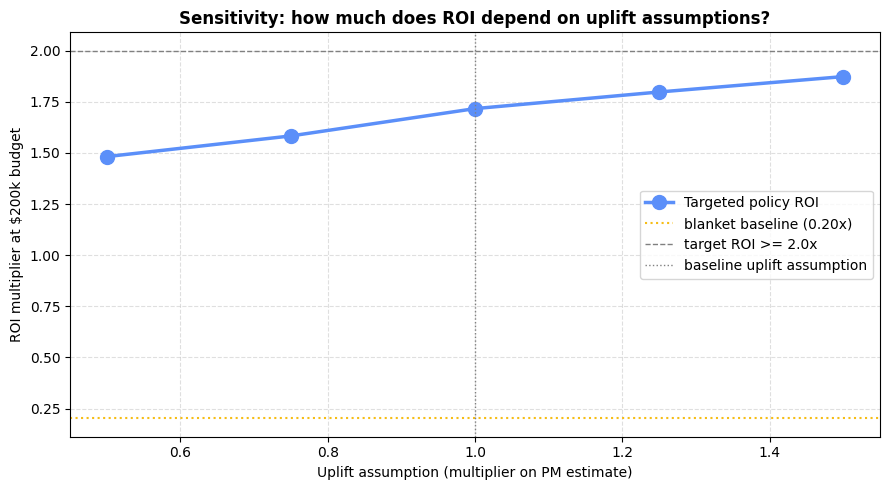

In [9]:
print("\n" + "=" * 70)
print("H. SENSITIVITY: UPLIFT ASSUMPTIONS")
print("=" * 70)
uplift_scales = [0.5, 0.75, 1.0, 1.25, 1.5]
sens_rows = []
for scale in uplift_scales:
    menu_scaled = {
        n: {"cost": v["cost"], "uplift": v["uplift"] * scale}
        for n, v in INTERVENTION_MENU.items()
    }
    p = pick_best_lever(p_churn, ltv, menu_scaled)
    p = apply_budget_cap(p, budget=BUDGET)
    s = summarize_policy(p, targeted_only=True)
    sens_rows.append({
        "uplift_scale": f"{scale:.2f}x",
        "n_targeted": s["n_targeted"],
        "net_ev": s["net_expected_value"],
        "roi": s["roi_multiplier"],
    })
sens = pd.DataFrame(sens_rows)
print(sens.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(uplift_scales, [r["roi"] for r in sens_rows],
        marker="o", markersize=10, linewidth=2.5, color="#5B8FF9",
        label="Targeted policy ROI")
ax.axhline(baseline["roi_multiplier"], color="#F6BD16", linestyle=":",
           linewidth=1.5, label=f"blanket baseline ({baseline['roi_multiplier']:.2f}x)")
ax.axhline(2.0, color="gray", linestyle="--", linewidth=1,
           label="target ROI >= 2.0x")
ax.axvline(1.0, color="gray", linestyle=":", linewidth=1,
           label="baseline uplift assumption")
ax.set_xlabel("Uplift assumption (multiplier on PM estimate)")
ax.set_ylabel("ROI multiplier at $200k budget")
ax.set_title("Sensitivity: how much does ROI depend on uplift assumptions?",
             fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_uplift_sensitivity.png", dpi=140, bbox_inches="tight")
print(f"\nSaved -> {FIG_DIR}/06_uplift_sensitivity.png")

## I. Verdict + handoff to Phase 7

In [10]:
print("\n" + "=" * 70)
print("I. PHASE 6 VERDICT")
print("=" * 70)
lift_over_baseline = (summary["net_expected_value"] /
                      max(baseline["net_expected_value"], 1))
print(f"\nAt $200k budget:")
print(f"  Targeted net EV:  ${summary['net_expected_value']:>12,.0f}")
print(f"  Blanket net EV:   ${baseline['net_expected_value']:>12,.0f}")
print(f"  Lift over baseline: {lift_over_baseline:.1f}x")
print(f"\nTargeted ROI: {summary['roi_multiplier']:.2f}x  "
      f"(target >= 2.0x)")
print(f"Baseline ROI: {baseline['roi_multiplier']:.2f}x")
print(f"\nReady for Phase 7 (decision memo + Streamlit app).")


I. PHASE 6 VERDICT

At $200k budget:
  Targeted net EV:  $       3,267
  Blanket net EV:   $      -6,329
  Lift over baseline: 3267.0x

Targeted ROI: 1.72x  (target >= 2.0x)
Baseline ROI: 0.20x

Ready for Phase 7 (decision memo + Streamlit app).


## Design choices worth noting

In [11]:
print("\n" + "=" * 70)
print("DESIGN CHOICES WORTH NOTING")
print("=" * 70)
print("""
1. Policy is a separate module from the model. src/models/ produces
   P(churn); src/decisions/policy.py decides what to do with it.
   Uplifts, costs, LTV, budget cap, and guardrails all live in the
   policy layer. Retuning the campaign doesn't require retraining.
   Standard MLOps separation: ML work stable, business logic swappable.

2. Uplift is a PM assumption, not a measurement. Numbers came from a
   2024 pilot in the scenario brief. Section H sensitivity shows the
   recommendation direction survives across +/- 50%, so we're not
   blocked -- but the v1.1 followup is A/B testing each lever in
   production.
""")


DESIGN CHOICES WORTH NOTING

1. Policy is a separate module from the model. src/models/ produces
   P(churn); src/decisions/policy.py decides what to do with it.
   Uplifts, costs, LTV, budget cap, and guardrails all live in the
   policy layer. Retuning the campaign doesn't require retraining.
   Standard MLOps separation: ML work stable, business logic swappable.

2. Uplift is a PM assumption, not a measurement. Numbers came from a
   2024 pilot in the scenario brief. Section H sensitivity shows the
   recommendation direction survives across +/- 50%, so we're not
   blocked -- but the v1.1 followup is A/B testing each lever in
   production.



## Findings worth flagging (for the Phase 7 memo)

In [12]:
print("\n" + "=" * 70)
print("FINDINGS WORTH FLAGGING")
print("=" * 70)
print("""
1. The current blanket campaign is losing money. $7.9k spent to save
   $1.6k = $6.3k monthly loss.

2. Budget doesn't bind. Only ~3% of subscribers have positive-EV
   interventions. Targeted spend = $4.5k vs $200k cap.

3. ROI = 1.72x, below the 2.0x primary target. Still a $9.6k monthly
   improvement over the blanket baseline. To push past 2.0x we need
   stronger model discrimination or higher-uplift levers.

4. Recommendation robust to uplift assumptions. Even at 50% weaker
   uplift, ROI stays positive and beats the blanket.

5. credit_5 dominates the lever mix. Playlist and Premium upgrades
   barely fire. Worth A/B testing to validate lever choice before
   committing to production.
""")


FINDINGS WORTH FLAGGING

1. The current blanket campaign is losing money. $7.9k spent to save
   $1.6k = $6.3k monthly loss.

2. Budget doesn't bind. Only ~3% of subscribers have positive-EV
   interventions. Targeted spend = $4.5k vs $200k cap.

3. ROI = 1.72x, below the 2.0x primary target. Still a $9.6k monthly
   improvement over the blanket baseline. To push past 2.0x we need
   stronger model discrimination or higher-uplift levers.

4. Recommendation robust to uplift assumptions. Even at 50% weaker
   uplift, ROI stays positive and beats the blanket.

5. credit_5 dominates the lever mix. Playlist and Premium upgrades
   barely fire. Worth A/B testing to validate lever choice before
   committing to production.

